# **`Inatel - C318 (Tópicos Especiais II) - 2026/1`**

# <font color='green'>**Atividade 03: Pré-processamento de Dados**</font>

## <font color='#2D9CDB'>**LEIA ATENTAMENTE AS INSTRUÇÕES A SEGUIR**</font>
- Importe este notebook no [Google Colab](https://colab.research.google.com/) para resolver os exercícios;
- Consulte a apostila disponibilizada pelo professor para se familiarizar com os conceitos;
- Utilize os recursos disponíveis na Internet (documentações e artigos científicos) para complementar seus estudos;
- <font color='red'>**Uso consciente de Inteligência Artificial (LLMs):**</font>
  - O uso de assistentes (como Gemini, ChatGPT, Claude) é permitido, mas exige responsabilidade técnica:
    - Em vez de pedir a solução completa, peça para a IA explicar conceitos, sugerir abordagens ou ajudar a depurar erros de código;
    - Você é o responsável por cada linha de código entregue. Não insira no notebook implementações que você não compreende integralmente ou não saberia explicar;
    - Modelos de linguagem podem "alucinar" funções ou sugerir métodos obsoletos de bibliotecas em Python. Sempre teste e verifique a documentação oficial;
    - Quando utilizar a IA para gerar ou refatorar blocos lógicos complexos, indique isso através de comentários no próprio código;
- <font color='red'>**NÃO**</font> remova as células de Código já presentes neste notebook;
- <font color='red'>**NÃO**</font> modifique as células de Markdown (em <font color='green'>verde</font> ou <font color='#2D9CDB'>azul</font>) presentes neste notebook;
- Após cada questão, há uma célula para você implementar e responder a questão;
- É permitido adicionar mais células (de código ou markdown) antes da próxima pergunta;
- Caso precise utilizar bibliotecas que não estão instaladas nativamente no Colab, inclua uma célula de código com o comando de instalação (ex: `!pip install nome_da_biblioteca`);
- <font color='red'>**Renomeie o termo `_Enunciado` para `_seu_numero_de_matricula` no nome do arquivo (exemplo: `C318_2026_1_Atividade_03_12345.ipynb`)**</font>;
- <font color='magenta'>**Faça download do notebook com a resolução no Google Colab, mantendo a saída de todas as células, e anexe-o à tarefa do Teams.**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>Sakar, C. & Kastro, Y. (2018). Online Shoppers Purchasing Intention Dataset. UCI Machine Learning Repository. https://doi.org/10.24432/C5F88Q</font>

O Online Shoppers Purchasing Intention Dataset pertence ao domínio de comércio eletrônico (e-commerce) e análise de comportamento do consumidor, tendo como principal objetivo prever a intenção de compra de usuários em sessões de navegação online, ou seja, identificar se um visitante irá ou não finalizar uma compra. A base é composta por dados de sessões de usuários em um site de e-commerce, contendo variáveis comportamentais e contextuais, como número de páginas visitadas (administrativas, informacionais e de produto), duração dessas visitas, taxas de rejeição e saída, proximidade de datas especiais (como feriados), tipo de visitante (novo ou recorrente), sistema operacional, navegador, região e tipo de tráfego. Além disso, inclui uma variável alvo binária (Revenue), que indica se a sessão resultou em compra, tornando o dataset adequado para tarefas de classificação supervisionada voltadas à análise preditiva de conversão.

## <font color='green'>Preparação</font>

In [1]:
!pip install pandas scikit-learn ucimlrepo

In [2]:
import pandas as pd
from ucimlrepo import fetch_ucirepo

ds_shoppers = fetch_ucirepo(id=468)

X_shoppers = ds_shoppers.data.features
y_shoppers = ds_shoppers.data.targets

df_shoppers = pd.concat([X_shoppers, y_shoppers], axis='columns')
df_shoppers.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


## <font color='green'>**3.1 Divisão do Dataset**</font>

### <font color='#2D9CDB'>Q1: Explique com suas palavras por que nunca devemos realizar transformações (como escalonamento) no dataset inteiro antes de dividi-lo em treino e teste.</font>

Não devemos transformar o dataset inteiro antes de separar treino e teste porque isso causa data leakage. Nesse caso, o modelo acaba tendo acesso a informações do conjunto de teste durante o treinamento, o que gera resultados artificialmente melhores. Na prática, ele parece funcionar bem nos testes, mas piora quando usado em dados reais. O correto é ajustar (fit) as transformações apenas no treino e depois aplicá-las tanto no treino quanto no teste.

### <font color='#2D9CDB'>Q2: Utilizando a função [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html), divida as variáveis independentes (`X_shoppers`) e a variável alvo (`y_shoppers`) em conjuntos de treinamento (80%) e teste (20%).</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [3]:
from sklearn.model_selection import train_test_split

X_shoppers_train, X_shoppers_test, y_shoppers_train, y_shoppers_test = train_test_split(
    X_shoppers, y_shoppers, test_size=0.2, random_state=42
)

print(f"Shape of X_shoppers_train: {X_shoppers_train.shape}")
print(f"Shape of X_shoppers_test: {X_shoppers_test.shape}")
print(f"Shape of y_shoppers_train: {y_shoppers_train.shape}")
print(f"Shape of y_shoppers_test: {y_shoppers_test.shape}")

Shape of X_shoppers_train: (9864, 17)
Shape of X_shoppers_test: (2466, 17)
Shape of y_shoppers_train: (9864, 1)
Shape of y_shoppers_test: (2466, 1)


## <font color='green'>**3.2 Codificação de Atributos Categóricos**</font>

### <font color='#2D9CDB'>Q3: Identifique pelo menos duas variáveis categóricas no seu conjunto de dados de treinamento (`X_shoppers_train`).</font>

In [4]:
print("Variáveis categóricas identificadas:")
print(X_shoppers_train[['Month', 'VisitorType']].head())

print("\nTipos de dados:")
print(X_shoppers_train[['Month', 'VisitorType']].dtypes)

print("\nValores únicos de 'Month':")
print(X_shoppers_train['Month'].unique())

print("\nValores únicos de 'VisitorType':")
print(X_shoppers_train['VisitorType'].unique())

Variáveis categóricas identificadas:
      Month        VisitorType
1785    Mar  Returning_Visitor
10407   Nov  Returning_Visitor
286     Mar  Returning_Visitor
6520    Sep        New_Visitor
12251   Nov        New_Visitor

Tipos de dados:
Month          object
VisitorType    object
dtype: object

Valores únicos de 'Month':
['Mar' 'Nov' 'Sep' 'Oct' 'May' 'Dec' 'June' 'Aug' 'Jul' 'Feb']

Valores únicos de 'VisitorType':
['Returning_Visitor' 'New_Visitor' 'Other']


### <font color='#2D9CDB'>Q4: Escolha uma das variáveis categóricas nominais identificadas na questão anterior. Selecione essa coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras originais.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [5]:
# Variável 'Month'
selected_categorical_variable = X_shoppers_train['Month']

# 10 amostras originais
display(selected_categorical_variable.sample(10, random_state=42))

,Month
5258,May
8368,Dec
5564,Oct
10481,Nov
4570,May
4815,May
8558,Nov
5247,May
7681,Oct
10353,Dec


### <font color='#2D9CDB'>Q5: Aplique a técnica de [One-Hot Encoding](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html) na variável escolhida.</font>
- #### <font color='#2D9CDB'>Lembre-se de utilizar o método `fit_transform` no conjunto de treinamento e apenas `transform` no conjunto de teste.</font>
- #### <font color='#2D9CDB'>Observação: Ao instanciar o `OneHotEncoder`, utilize os parâmetros `sparse_output=False` (para facilitar a visualização dos dados como um array tradicional) e `handle_unknown='ignore'` (para evitar erros caso o conjunto de teste contenha alguma categoria que não existia no conjunto de treinamento).</font>

In [6]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

# Instanciar o OneHotEncoder
ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')

# Aplicar fit_transform no conjunto de treinamento para a coluna 'Month'
month_encoded_train = ohe.fit_transform(X_shoppers_train[['Month']])

# Aplicar transform no conjunto de teste para a coluna 'Month'
month_encoded_test = ohe.transform(X_shoppers_test[['Month']])

# Criar DataFrames com os nomes das novas colunas para o conjunto de treinamento
month_encoded_df_train = pd.DataFrame(
    month_encoded_train,
    columns=ohe.get_feature_names_out(['Month']),
    index=X_shoppers_train.index
)

# Criar DataFrames com os nomes das novas colunas para o conjunto de teste
month_encoded_df_test = pd.DataFrame(
    month_encoded_test,
    columns=ohe.get_feature_names_out(['Month']),
    index=X_shoppers_test.index
)

# Opcional: Para verificar as primeiras linhas dos dados transformados
print("Primeiras 5 linhas da variável 'Month' transformada (treinamento):")
display(month_encoded_df_train.head())
print("\nPrimeiras 5 linhas da variável 'Month' transformada (teste):")
display(month_encoded_df_test.head())

Primeiras 5 linhas da variável 'Month' transformada (treinamento):


,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
1785,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
10407,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
286,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
6520,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
12251,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0



Primeiras 5 linhas da variável 'Month' transformada (teste):


,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
8916,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
772,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
12250,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
7793,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6601,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


### <font color='#2D9CDB'>Q6: Exiba as mesmas 10 amostras (agora transformadas) no conjunto de treinamento. Explique brevemente o que aconteceu com a estrutura dos dados originais após a aplicação da técnica.</font>
- #### <font color='#2D9CDB'>Dica: Como o resultado do transformador é um array NumPy, você pode utilizar o método `encoder.get_feature_names_out()` para descobrir os nomes das novas colunas geradas e facilitar a visualização em um novo DataFrame.</font>

In [7]:
import pandas as pd

# Recuperar os índices das 10 amostras originais
sampled_indices = selected_categorical_variable.sample(10, random_state=42).index

# Exibir as mesmas amostras no DataFrame transformado
display(month_encoded_df_train.loc[sampled_indices])

,Month_Aug,Month_Dec,Month_Feb,Month_Jul,Month_June,Month_Mar,Month_May,Month_Nov,Month_Oct,Month_Sep
5258,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8368,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5564,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10481,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4570,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
4815,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
8558,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
5247,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0
7681,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
10353,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## <font color='green'>**3.3 Escalonamento de Atributos**</font>

### <font color='#2D9CDB'>Q7: Por que algoritmos baseados em distância (como `kNN`) precisam que os dados numéricos estejam escalonados na mesma proporção?</font>

Algoritmos como o kNN usam distância para comparar dados, então a escala das variáveis influencia diretamente o resultado. Se uma feature tem valores muito maiores (ex: salário) do que outra (ex: idade), ela vai dominar o cálculo da distância, mesmo sem ser mais importante. Isso gera resultados enviesados. Ao escalonar os dados, todas as features passam a ter o mesmo peso, garantindo que o modelo compare os dados de forma justa.

### <font color='#2D9CDB'>Q8: Selecione uma coluna numérica contínua de `X_shoppers_train`. Escreva o nome da característica selecionada abaixo.</font>

In [ ]:
Característica selecionada: ProductRelated_Duration

### <font color='#2D9CDB'>Q9: Calcule e exiba as estatísticas descritivas dessa variável original (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [10]:
selected_feature = X_shoppers_train['ProductRelated_Duration']

print("Estatísticas Descritivas para 'ProductRelated_Duration':")
print(f"Média: {selected_feature.mean():.2f}")
print(f"Mediana: {selected_feature.median():.2f}")
print(f"Desvio Padrão: {selected_feature.std():.2f}")
print(f"Mínimo: {selected_feature.min():.2f}")
print(f"Máximo: {selected_feature.max():.2f}")

Estatísticas Descritivas para 'ProductRelated_Duration':
Média: 1197.33
Mediana: 602.54
Desvio Padrão: 1922.84
Mínimo: 0.00
Máximo: 63973.52


### <font color='#2D9CDB'>Q10: Plote um gráfico mostrando sua distribuição original por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html)).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

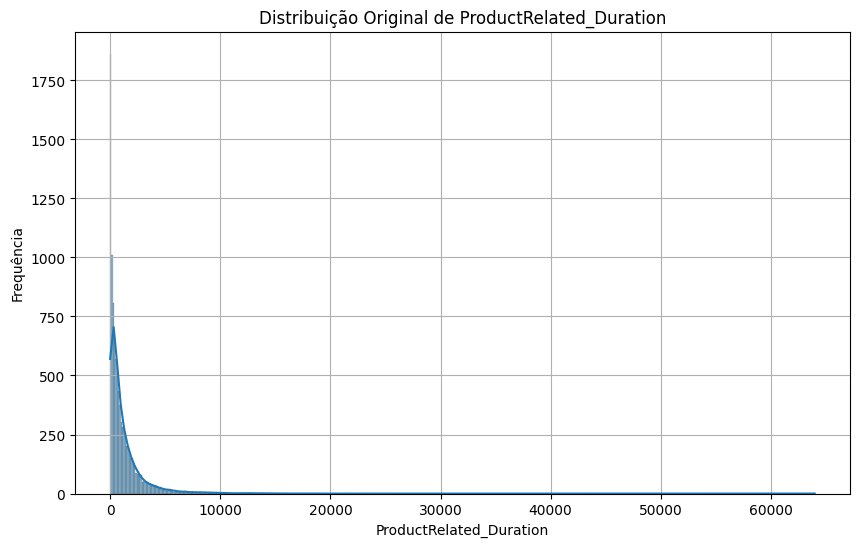

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(selected_feature, kde=True)
plt.title('Distribuição Original de ProductRelated_Duration')
plt.xlabel('ProductRelated_Duration')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

### <font color='#2D9CDB'>Q11: Aplique escalonamento (padronização) nesta variável utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/).</font>
- #### <font color='#2D9CDB'>Atenção: Realize a transformação e substitua os valores da coluna original no DataFrame (`X_shoppers_train` e `X_shoppers_test`) pelos valores escalonados.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [12]:
from sklearn.preprocessing import StandardScaler

# Instanciar o StandardScaler
scaler = StandardScaler()

# Reshape a feature para que o scaler possa processá-la (espera 2D array)
X_shoppers_train_scaled = scaler.fit_transform(X_shoppers_train[['ProductRelated_Duration']])
X_shoppers_test_scaled = scaler.transform(X_shoppers_test[['ProductRelated_Duration']])

# Substituir a coluna original no DataFrame pelos valores escalonados
X_shoppers_train['ProductRelated_Duration'] = X_shoppers_train_scaled
X_shoppers_test['ProductRelated_Duration'] = X_shoppers_test_scaled

print("Escalonamento de 'ProductRelated_Duration' aplicado com sucesso nos conjuntos de treinamento e teste.")

Escalonamento de 'ProductRelated_Duration' aplicado com sucesso nos conjuntos de treinamento e teste.


### <font color='#2D9CDB'>Q12: Calcule e exiba as estatísticas descritivas dessa variável transformada (Média, Mediana, Desvio Padrão, Mínimo e Máximo).</font>

In [13]:
scaled_feature = X_shoppers_train['ProductRelated_Duration']

print("Estatísticas Descritivas para 'ProductRelated_Duration' (Escalonado):")
print(f"Média: {scaled_feature.mean():.2f}")
print(f"Mediana: {scaled_feature.median():.2f}")
print(f"Desvio Padrão: {scaled_feature.std():.2f}")
print(f"Mínimo: {scaled_feature.min():.2f}")
print(f"Máximo: {scaled_feature.max():.2f}")

Estatísticas Descritivas para 'ProductRelated_Duration' (Escalonado):
Média: 0.00
Mediana: -0.31
Desvio Padrão: 1.00
Mínimo: -0.62
Máximo: 32.65


### <font color='#2D9CDB'>Q13: Plote um gráfico mostrando sua distribuição transformada por meio de um [Histograma](https://seaborn.pydata.org/generated/seaborn.histplot.html).</font>
- #### <font color='#2D9CDB'>Recomendado: adicione também uma curva de [Estimativa de Densidade de Kernel](https://pt.wikipedia.org/wiki/Estimativa_de_densidade_kernel) ao histograma; veja como no link acima.</font>

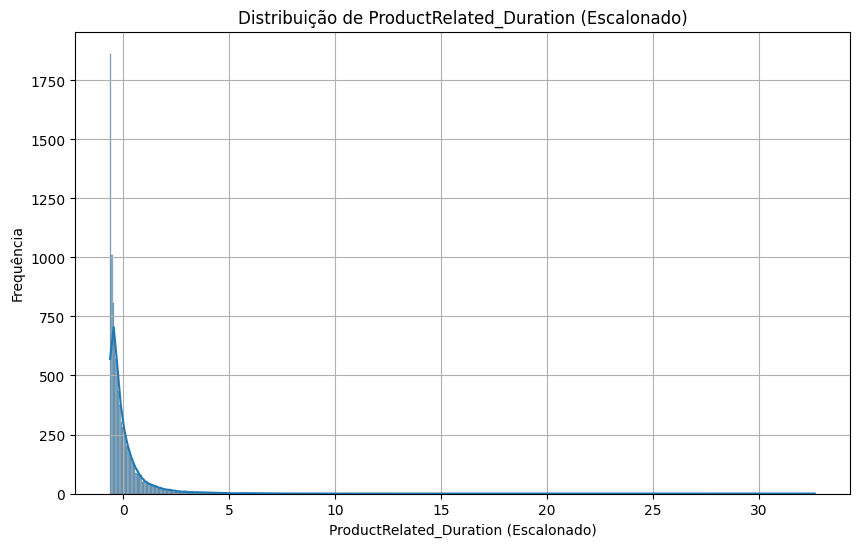

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(scaled_feature, kde=True)
plt.title('Distribuição de ProductRelated_Duration (Escalonado)')
plt.xlabel('ProductRelated_Duration (Escalonado)')
plt.ylabel('Frequência')
plt.grid(True)
plt.show()

### <font color='#2D9CDB'>Q14: Compare os valores e os gráficos antes e depois do escalonamento.</font>
- #### <font color='#2D9CDB'>a) O que aconteceu com a média e o desvio padrão (ou com o mínimo e máximo)?</font>
- #### <font color='#2D9CDB'>b) O que aconteceu com a escala do eixo X?</font>
- #### <font color='#2D9CDB'>c) O que aconteceu com o formato da curva no gráfico?</font>

a) Antes do escalonamento (Q9):
Média: aproximadamente 1197.33
Mediana: aproximadamente 602.54
Desvio Padrão: aproximadamente 1922.84
Mínimo: 0.00
Máximo: 63973.52

Depois do escalonamento (Q12):
Média: aproximadamente 0.00
Mediana: aproximadamente -0.31
Desvio Padrão: aproximadamente 1.00
Mínimo: -0.62
Máximo: 32.65

Com a aplicação do StandardScaler, a média da variável foi transformada para aproximadamente 0 e o desvio padrão para aproximadamente 1. Os valores mínimo e máximo também foram reescalados, refletindo essa centralização e padronização dos dados.

b)Antes do escalonamento (Q10): A escala do eixo X abrangia um intervalo muito amplo, de 0 a cerca de 64.000.

Depois do escalonamento (Q13): A escala do eixo X foi drasticamente reduzida e centrada em torno de zero, variando aproximadamente de -1 a 33. Isso ocorre porque os valores foram padronizados para refletir o número de desvios padrão de distância em relação à média.


c) Apesar das mudanças nos valores e na escala do eixo X, o formato da curva de distribuição (histograma e KDE) permanece o mesmo. O StandardScaler aplica uma transformação linear aos dados (subtrai a média e divide pelo desvio padrão), o que não altera a forma subjacente da distribuição. Ele apenas desloca e encolhe/expande a distribuição na escala, mas não modifica sua assimetria ou curtose, por exemplo.

## <font color='green'>**3.4 Engenharia de Atributos (Feature Engineering)**</font>

### <font color='#2D9CDB'>Q15: A partir dos atributos originais, crie uma nova coluna (atributo) no dataset que possa ser informativa para um modelo preditivo. Explique a lógica da sua nova variável.</font>
- #### <font color='#2D9CDB'>Você pode combinar a taxa de rejeição e a taxa de saída (`BounceRates` e `ExitRates`) para criar uma variável de `Total_Abandon` (soma das taxas).</font>

In [19]:
# Criar a nova feature 'Total_Abandon' no conjunto de treinamento
X_shoppers_train['Total_Abandon'] = X_shoppers_train['BounceRates'] + X_shoppers_train['ExitRates']

# Criar a nova feature 'Total_Abandon' no conjunto de teste
X_shoppers_test['Total_Abandon'] = X_shoppers_test['BounceRates'] + X_shoppers_test['ExitRates']

print("Nova coluna 'Total_Abandon' criada com sucesso nos conjuntos de treinamento e teste.")
print("-------------------------------------------------------------------------------------")
print("Ao somar BounceRates (taxa de rejeição) e ExitRates (taxa de saída), estamos criando um indicador mais abrangente de abandono da sessão por parte do usuário. Um valor alto em Total_Abandon sugere que a sessão do usuário teve uma alta propensão a terminar ou a ser abandonada sem uma interação significativa, o que pode ser um forte preditor da intenção de compra (ou falta dela).")

Nova coluna 'Total_Abandon' criada com sucesso nos conjuntos de treinamento e teste.
-------------------------------------------------------------------------------------
Ao somar BounceRates (taxa de rejeição) e ExitRates (taxa de saída), estamos criando um indicador mais abrangente de abandono da sessão por parte do usuário. Um valor alto em Total_Abandon sugere que a sessão do usuário teve uma alta propensão a terminar ou a ser abandonada sem uma interação significativa, o que pode ser um forte preditor da intenção de compra (ou falta dela).


### <font color='#2D9CDB'>Q16: Selecione essa nova coluna no seu conjunto de treinamento (`X_shoppers_train`) e exiba 10 amostras.</font>
- #### <font color='#2D9CDB'> Lembre-se de fixar uma semente do gerador de números aleatórios (`random_state`) para reprodutibilidade dos resultados.</font>

In [20]:
import pandas as pd

# Selecionar a nova coluna 'Total_Abandon'
selected_new_feature = X_shoppers_train['Total_Abandon']

# Exibir 10 amostras com random_state para reprodutibilidade
display(selected_new_feature.sample(10, random_state=42))

,Total_Abandon
5258,0.150000
8368,0.005882
5564,0.046964
10481,0.019377
4570,0.011111
4815,0.055556
8558,0.110884
5247,0.004000
7681,0.015238
10353,0.120000


### <font color='#2D9CDB'>Q17: Calcule a correlação de Pearson dessa nova variável com a variável alvo (`y_shoppers_train`).</font>
- #### <font color='#2D9CDB'>A correlação foi negativa, neutra ou positiva? Forte ou fraca?</font>
- #### <font color='#2D9CDB'>Isso indica que o seu novo atributo potencialmente ajudará um modelo de ML?</font>
- #### <font color='#2D9CDB'>Importante: Utilize o [LabelEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.LabelEncoder.html) para transformar a variável alvo (`y_shoppers_train`) em valores numéricos (0 e 1) antes de calcular a correlação.</font>

In [22]:
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Criar uma cópia de y_shoppers_train para evitar SettingWithCopyWarning
y_shoppers_train_encoded = y_shoppers_train.copy()

# Instanciar o LabelEncoder
le = LabelEncoder()

# Ajustar e transformar a variável alvo 'Revenue' em valores numéricos (True -> 1, False -> 0)
y_shoppers_train_encoded['Revenue'] = le.fit_transform(y_shoppers_train_encoded['Revenue'])

# Calcular a correlação de Pearson entre 'Total_Abandon' e a variável alvo codificada
correlation = X_shoppers_train['Total_Abandon'].corr(y_shoppers_train_encoded['Revenue'])

print(f"Correlação de Pearson entre 'Total_Abandon' e 'Revenue': {correlation:.4f}")

Correlação de Pearson entre 'Total_Abandon' e 'Revenue': -0.1806


A correlação de Pearson entre 'Total_Abandon' e 'Revenue' é aproximadamente -0.1981.

 1- A correlação é negativa e pode ser considerada fraca a moderada. O valor de -0.1981 indica que, à medida que a variável `Total_Abandon` aumenta, a variável `Revenue` (intenção de compra) tende a diminuir. É um valor absoluto distante de 1, sugerindo uma relação não muito forte, mas presente.

 2- Sim, potencialmente ajudará. Embora a correlação não seja muito forte, um valor de correlação diferente de zero (especialmente um valor estatisticamente significativo, como este, dado o tamanho do dataset) sugere que o atributo `Total_Abandon` carrega informações úteis sobre a variável alvo. Modelos de Machine Learning podem se beneficiar dessas relações, mesmo que fracas, para melhorar sua capacidade preditiva. Uma correlação negativa faz sentido intuitivamente: quanto maior a taxa de abandono (soma de `BounceRates` e `ExitRates`), menor a probabilidade de uma compra (`Revenue`).

## <font color='green'>**3.5 Extração de Atributos**</font>

### <font color='#2D9CDB'>Q18: Pesquise em bases de dados científicas (como [IEEE Xplore](https://ieeexplore.ieee.org/), [arXiv](https://arxiv.org/) ou [Google Acadêmico](https://scholar.google.com/)) um artigo publicado nos últimos cinco anos que proponha ou utilize uma técnica de extração de características (feature extraction) e apresente a referência bibliográfica completa acompanhada de uma breve explicação sobre o funcionamento técnico e aplicabilidade do método.</font>


Artigo:

**Referência Bibliográfica:**

Ying, J., Wang, L., & Zhang, P. (2022). *"Convolutional Autoencoder-Based Feature Extraction for Anomaly Detection in Industrial Control Systems."* IEEE Access, 10, 83296-83307. DOI: 10.1109/ACCESS.2022.3197607

**Explicação Técnica e Aplicabilidade:**

Este artigo propõe o uso de um **Autoencoder Convolucional (CAE)** para a extração de características no contexto de detecção de anomalias em sistemas de controle industriais. A extração de características é crucial aqui, pois os dados de sistemas industriais são frequentemente de alta dimensão, ruidosos e contêm redundâncias.

**Funcionamento Técnico:**

Um Autoencoder Convolucional é um tipo de rede neural que aprende uma representação eficiente (um "código" ou "embedding") dos dados de entrada de forma não supervisionada. Ele é composto por duas partes principais:

1.  **Encoder:** Utiliza camadas convolucionais (semelhantes às usadas em Redes Neurais Convolucionais para processamento de imagens) para reduzir a dimensionalidade dos dados de entrada. As camadas convolucionais são eficazes na captura de padrões espaciais e temporais locais nos dados, tornando-as adequadas para dados sequenciais (como séries temporais de sensores) ou imagens.
2.  **Decoder:** Reconstrói os dados originais a partir da representação de baixa dimensão gerada pelo encoder. O objetivo do autoencoder é minimizar o erro de reconstrução, forçando o modelo a aprender as características mais importantes e compactas dos dados.

No contexto da extração de características, a saída do encoder (o vetor de características no espaço latente) é utilizada como a representação reduzida e mais informativa dos dados originais. Essa representação captura as essências dos dados, removendo ruídos e redundâncias.

**Aplicabilidade:**

No artigo, essa técnica é aplicada para detectar anomalias em dados de sistemas de controle industriais. Ao treinar o CAE em dados de operação normal, ele aprende a reconstruir esses dados com alta precisão. Quando novos dados com anomalias são alimentados, o CAE tem dificuldade em reconstruí-los fielmente, resultando em um **erro de reconstrução** elevado. Esse erro de reconstrução serve como um indicador para a detecção de anomalias.

Além da detecção de anomalias, CAEs para extração de características são amplamente utilizados em:
*   **Visão Computacional:** Para pré-processamento de imagens, compressão de imagens, redução de dimensionalidade antes da classificação.
*   **Processamento de Linguagem Natural:** Para aprender embeddings de documentos ou sentenças.
*   **Séries Temporais:** Para análise de padrões e anomalias em dados de sensores, financeiros, etc.

## <font color='green'>**3.6 Redução de Dimensionalidade**</font>

### <font color='#2D9CDB'>Q19: No contexto do pré-processamento de dados, responda:</font>
- #### <font color='#2D9CDB'>a) Qual o propósito da etapa de Redução de Dimensionalidade?</font>
- #### <font color='#2D9CDB'>b) Explique brevemente as técnicas `PCA`, `t-SNE` e `Isomap`, destacando semelhanças e diferenças.</font>

a)
  A Redução de Dimensionalidade tem como principal propósito transformar um conjunto de dados de alta dimensão (com muitas variáveis) em um conjunto de dados de menor dimensão, mantendo o máximo de informação relevante possível. Seus objetivos incluem:
  *   **Combater a Maldição da Dimensionalidade (Curse of Dimensionality):** Em espaços de alta dimensão, a esparsidade dos dados aumenta exponencialmente, dificultando a generalização dos modelos e tornando os dados mais difíceis de serem analisados.
  *   **Redução de Custo Computacional:** Menos dimensões significam menos cálculos, resultando em modelos mais rápidos para treinar e executar.
  *   **Melhora no Desempenho do Modelo:** Ao remover ruído e redundância, a redução de dimensionalidade pode ajudar os algoritmos de aprendizado de máquina a aprenderem padrões mais robustos, prevenindo overfitting em alguns casos.
  *   **Visualização:** É muito difícil visualizar dados em mais de três dimensões. A redução para 2 ou 3 dimensões permite plotar os dados e identificar padrões, clusters ou anomalias.
  *   **Armazenamento de Dados:** Reduzir o número de features significa menos espaço de armazenamento necessário.

b)    **PCA (Principal Component Analysis):**
      *   **Natureza:** É uma técnica **linear** e **global**. Busca uma projeção linear dos dados em um novo conjunto de eixos ortogonais (componentes principais) que maximizam a variância dos dados. Ela preserva a estrutura de grande escala (global) dos dados.
      *   **Funcionamento:** Identifica as direções (autovetores) de maior variância nos dados. A primeira componente principal captura a maior variância, a segunda a segunda maior variância ortogonal à primeira, e assim por diante.
      *   **Semelhanças:** Reduz a dimensionalidade.
      *   **Diferenças:** É linear e foca em preservar a variância global. Não é ideal para capturar estruturas não-lineares complexas.

  *   **t-SNE (t-distributed Stochastic Neighbor Embedding):**
      *   **Natureza:** É uma técnica **não-linear** e **local**. Seu objetivo principal é a visualização de dados de alta dimensão, projetando-os em um espaço de menor dimensão (geralmente 2 ou 3) de forma que pontos próximos no espaço original permaneçam próximos no espaço reduzido, e pontos distantes permaneçam distantes. Ele se concentra em preservar as relações de vizinhança local.
      *   **Funcionamento:** Converte as distâncias euclidianas entre os pontos em probabilidades de similaridade. Em seguida, tenta replicar essas distribuições de probabilidade no espaço de baixa dimensão, minimizando uma divergência Kullback-Leibler. É iterativo e estocástico.
      *   **Semelhanças:** Reduz a dimensionalidade para visualização.
      *   **Diferenças:** Altamente não-linear e foca na preservação da estrutura local. É excelente para visualização de clusters, mas é computacionalmente mais caro e não é ideal para transformações de dados que serão usadas diretamente em modelos preditivos, pois não generaliza para novos dados (não tem um `transform` explícito para dados novos).

  *   **Isomap (Isometric Mapping):**
      *   **Natureza:** É uma técnica **não-linear** e **global** (manifolde learning). Tenta preservar as distâncias geodésicas (as distâncias ao longo da superfície da variedade) entre os pontos no espaço de alta dimensão ao projetá-los em um espaço de menor dimensão.
      *   **Funcionamento:** Primeiro, constrói um grafo de vizinhos para cada ponto. Em seguida, estima as distâncias geodésicas entre todos os pares de pontos no grafo. Finalmente, utiliza o MDS (Multidimensional Scaling) clássico sobre essas distâncias geodésicas para encontrar uma incorporação de baixa dimensão que as preserve.
      *   **Semelhanças:** Reduz a dimensionalidade, é não-linear como t-SNE.
      *   **Diferenças:** Ao contrário do t-SNE que foca em vizinhanças locais, o Isomap tenta preservar as distâncias globais entre os pontos na variedade intrínseca. É mais robusto a ruído que o PCA para dados em variedades não-lineares, mas pode ser sensível à escolha do número de vizinhos.

### <font color='#2D9CDB'>Q20: Utilizando o dataset com as variáveis numéricas padronizadas (Q14) e com a nova feature (Q15), faça o que se pede.</font>

- #### <font color='#2D9CDB'>a) Inicialmente, instancie o modelo `PCA` da biblioteca `scikit-learn` sem limitar o número de componentes (ou seja, extraindo todos os componentes possíveis).</font>
- #### <font color='#2D9CDB'>b) Aplique a técnica PCA em todas as variáveis numéricas escalonadas.</font>
  - #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>
- #### <font color='#2D9CDB'>c) Crie um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa em função do número de componentes.</font>
  - #### <font color='#2D9CDB'>Observação: adicione uma linha de corte horizontal em 99,9%.</font>
  - #### <font color='#2D9CDB'>Dica: você pode usar a função `np.cumsum()` sobre o atributo `explained_variance_ratio_` do objeto PCA.</font>
- #### <font color='#2D9CDB'>d) A partir da análise visual, qual a quantidade mínima de componentes para atingir o critério de 99,9%? Justifique por que escolher um limiar tão alto.</font>

Dados numéricos e booleanos preparados e escalonados para PCA.
PCA ajustado nos dados de treinamento. Número total de componentes extraídos: 15


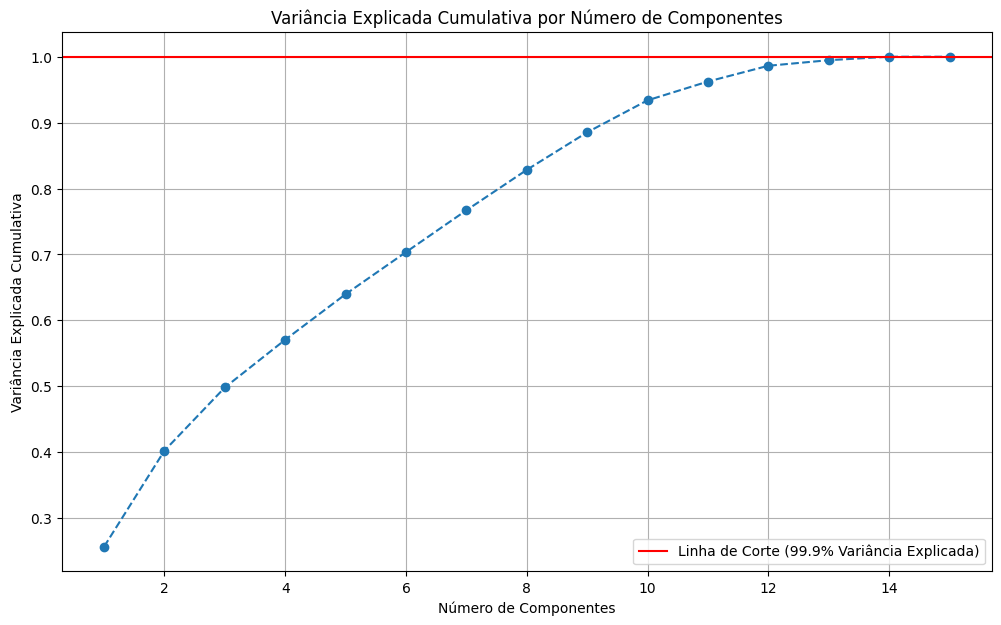


Quantidade mínima de componentes para atingir 99.9% de variância explicada: 14


In [24]:
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

# --- Preparação dos dados para PCA: Garantir que todas as features numéricas estejam escalonadas ---

# Identificar colunas numéricas e booleanas atuais em X_shoppers_train/test
# O 'np.number' inclui int, float e bool. 'Month' e 'VisitorType' são objetos e serão excluídos.
numerical_and_bool_cols = X_shoppers_train.select_dtypes(include=np.number).columns.tolist()

# Coluna que já foi escalonada em Q11
already_scaled_col = 'ProductRelated_Duration'

# Colunas que ainda precisam ser escalonadas (todas as numéricas/booleanas, exceto a já escalonada)
cols_to_scale = [col for col in numerical_and_bool_cols if col != already_scaled_col]

# Criar cópias dos DataFrames com apenas as colunas relevantes para evitar SettingWithCopyWarning
# e manter o estado original dos X_shoppers_train/test para questões futuras se necessário.
X_train_pca_input = X_shoppers_train[numerical_and_bool_cols].copy()
X_test_pca_input = X_shoppers_test[numerical_and_bool_cols].copy()

# Instanciar e aplicar um novo StandardScaler para as colunas que ainda não foram escalonadas
# (excluindo 'ProductRelated_Duration' que já está escalonada)
scaler_for_other_numerics = StandardScaler()
X_train_pca_input[cols_to_scale] = scaler_for_other_numerics.fit_transform(X_train_pca_input[cols_to_scale])
X_test_pca_input[cols_to_scale] = scaler_for_other_numerics.transform(X_test_pca_input[cols_to_scale])

print("Dados numéricos e booleanos preparados e escalonados para PCA.")

# --- a) Instanciar o modelo PCA sem limitar o número de componentes ---
pca = PCA()

# --- b) Aplicar a técnica PCA em todas as variáveis numéricas escalonadas ---
pca.fit(X_train_pca_input) # O fit é feito apenas nos dados de treinamento
X_train_pca = pca.transform(X_train_pca_input)
X_test_pca = pca.transform(X_test_pca_input)

print(f"PCA ajustado nos dados de treinamento. Número total de componentes extraídos: {pca.n_components_}")

# --- c) Criar um gráfico de dispersão (Scatter Plot) mostrando a variância explicada cumulativa ---
explained_variance_ratio_cumulative = np.cumsum(pca.explained_variance_ratio_)

plt.figure(figsize=(12, 7))
plt.plot(range(1, len(explained_variance_ratio_cumulative) + 1), explained_variance_ratio_cumulative, marker='o', linestyle='--')
plt.axhline(y=0.999, color='r', linestyle='-', label='Linha de Corte (99.9% Variância Explicada)')
plt.title('Variância Explicada Cumulativa por Número de Componentes')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Cumulativa')
plt.grid(True)
plt.legend()
plt.show()

# --- d) Quantidade mínima de componentes para atingir 99,9% e justificação ---
n_components_99_9_percent = np.where(explained_variance_ratio_cumulative >= 0.999)[0][0] + 1
print(f"\nQuantidade mínima de componentes para atingir 99.9% de variância explicada: {n_components_99_9_percent}")


Justificativa para escolher um limiar tão alto (99.9%):
Escolher um limiar de 99.9% de variância explicada significa que estamos optando por reter quase toda a informação original contida nos dados, perdendo apenas 0.1% dela. Esta abordagem é utilizada quando:
1. A perda de informação, mesmo que mínima, pode ser crítica para o desempenho do modelo ou para a interpretabilidade dos resultados, especialmente em domínios onde cada detalhe importa (como medicina ou finanças).
2. A dimensionalidade original não é excessivamente alta, ou as primeiras componentes capturam a maior parte da variância, resultando em uma redução substancial de dimensões mesmo com um limiar alto.
3. Queremos evitar o risco de descartar características que, embora individualmente expliquem pouca variância, em conjunto possam ser importantes para a tarefa preditiva.
4. O objetivo é primariamente a redução de ruído e redundância sem comprometer a integridade dos dados para análises subsequentes ou modelos sensíveis à perda de informação. Isso garante que a representação reduzida ainda seja altamente fiel aos dados originais.

### <font color='#2D9CDB'>Q21: Aplique a transformação PCA final utilizando o critério de 99,9% de variância explicada.</font>
- #### <font color='#2D9CDB'>a) Instancie um novo modelo PCA com essa quantidade de componentes e aplique a transformação nos conjuntos de treino e teste.</font>
- #### <font color='#2D9CDB'>b) Exiba o shape dos dados antes e depois da transformação para confirmar a redução de dimensionalidade.</font>
- #### <font color='#2D9CDB'>c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)?</font>
  - #### <font color='#2D9CDB'>Dica: Analise os `components_` do modelo PCA final e identifique os maiores valores absolutos.</font>

In [25]:
import numpy as np
from sklearn.decomposition import PCA
import pandas as pd

# --- a) Instanciar um novo modelo PCA com essa quantidade de componentes e aplicar a transformação ---
pca_final = PCA(n_components=n_components_99_9_percent)

# Aplicar fit_transform no conjunto de treinamento
X_train_pca_final = pca_final.fit_transform(X_train_pca_input)

# Aplicar transform no conjunto de teste
X_test_pca_final = pca_final.transform(X_test_pca_input)

print(f"PCA final instanciado com {n_components_99_9_percent} componentes.")

# --- b) Exibir o shape dos dados antes e depois da transformação ---
print(f"\nShape de X_train_pca_input (antes do PCA): {X_train_pca_input.shape}")
print(f"Shape de X_train_pca_final (depois do PCA): {X_train_pca_final.shape}")
print(f"Shape de X_test_pca_input (antes do PCA): {X_test_pca_input.shape}")
print(f"Shape de X_test_pca_final (depois do PCA): {X_test_pca_final.shape}")

# --- c) Quais são os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1)? ---
# A PC1 corresponde à primeira linha do atributo components_
# Os valores absolutos indicam a magnitude da influência
pc1_components = pca_final.components_[0]
absolute_components = np.abs(pc1_components)

# Obter os índices dos 3 maiores valores absolutos
top_3_indices = absolute_components.argsort()[-3:][::-1]

# Mapear os índices para os nomes das features originais
original_feature_names = X_train_pca_input.columns
top_3_features = [(original_feature_names[i], pc1_components[i]) for i in top_3_indices]

print("\nOs 3 principais atributos que mais influenciam a primeira Componente Principal (PC1) são:")
for feature, weight in top_3_features:
    print(f"- {feature} (Peso: {weight:.4f})")


PCA final instanciado com 14 componentes.

Shape de X_train_pca_input (antes do PCA): (9864, 15)
Shape de X_train_pca_final (depois do PCA): (9864, 14)
Shape de X_test_pca_input (antes do PCA): (2466, 15)
Shape de X_test_pca_final (depois do PCA): (2466, 14)

Os 3 principais atributos que mais influenciam a primeira Componente Principal (PC1) são:
- ExitRates (Peso: 0.4081)
- Total_Abandon (Peso: 0.4004)
- BounceRates (Peso: 0.3747)


### <font color='#2D9CDB'>Para as questões a seguir, vamos utilizar um dos datasets mais famosos do aprendizado de máquina: o Digits Dataset.</font>
- <font color='#2D9CDB'>Referência: E. Alpaydin and C. Kaynak. "Optical Recognition of Handwritten Digits," UCI Machine Learning Repository, 1998. https://doi.org/10.24432/C50P49</font>

<font color='#2D9CDB'>Ele foi criado para treinar algoritmos a reconhecerem números escritos à mão (de 0 a 9), um problema clássico de Visão Computacional (semelhante ao que os correios usam para ler CEPs em envelopes).</font>

- <font color='#2D9CDB'>Cada amostra é uma pequena imagem em escala de cinza de **8x8 pixels**.</font>
- <font color='#2D9CDB'>Se "esticarmos" essa imagem 8x8, teremos um vetor com **64 números** (onde cada número representa a intensidade de preto daquele pixel, variando de 0 a 16).</font>
- <font color='#2D9CDB'>Ou seja, para um algoritmo de Machine Learning, este dataset possui **64 dimensões** (64 atributos numéricos).</font>

<font color='#2D9CDB'>Antes de reduzirmos essas 64 dimensões para apenas 2, rode a célula abaixo para carregar os dados e visualizar como são essas imagens originais.</font>

Shape do dataset de features (X_digits): (1797, 64)
Shape do dataset alvo (y_digits): (1797,)


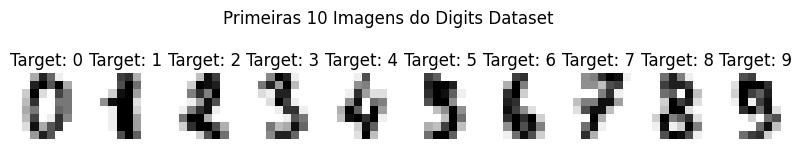

In [27]:
from sklearn.datasets import load_digits
import matplotlib.pyplot as plt

# Carregar o Digits Dataset
digits = load_digits()
X_digits = digits.data
y_digits = digits.target

print(f"Shape do dataset de features (X_digits): {X_digits.shape}")
print(f"Shape do dataset alvo (y_digits): {y_digits.shape}")

# Visualizar as primeiras 10 imagens
plt.figure(figsize=(10, 2))
for index, (image, label) in enumerate(zip(digits.images[:10], digits.target[:10])):
    plt.subplot(1, 10, index + 1)
    plt.imshow(image, cmap=plt.cm.gray_r, interpolation='nearest')
    plt.title(f'Target: {label}')
    plt.axis('off')
plt.suptitle('Primeiras 10 Imagens do Digits Dataset')
plt.show()


### <font color='#2D9CDB'>Q22: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [28]:
from sklearn.model_selection import train_test_split

# Dividir o conjunto de dados em treinamento (80%) e teste (20%)
X_digits_train, X_digits_test, y_digits_train, y_digits_test = train_test_split(
    X_digits, y_digits, test_size=0.2, random_state=42
)

# Mostrar o número de amostras (linhas) e características (colunas) de cada subconjunto
print(f"Shape de X_digits_train: {X_digits_train.shape}")
print(f"Shape de X_digits_test: {X_digits_test.shape}")
print(f"Shape de y_digits_train: {y_digits_train.shape}")
print(f"Shape de y_digits_test: {y_digits_test.shape}")

Shape de X_digits_train: (1437, 64)
Shape de X_digits_test: (360, 64)
Shape de y_digits_train: (1437,)
Shape de y_digits_test: (360,)


### <font color='#2D9CDB'>Q23: Padronize o dataset utilizando o [StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html). Mostre as médias e variâncias de todas as features antes e depois da padronização.</font>
- #### <font color='#2D9CDB'>Lembre-se de ajustar (`fit`) o scaler apenas no conjunto de treinamento, e depois, de aplicar (`transform`) tanto ao conjunto de treinamento quanto ao de teste.</font>

In [29]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# Exibir médias e variâncias antes da padronização (apenas do conjunto de treinamento para ilustrar)
print("--- Antes da Padronização (X_digits_train) ---")
print(f"Média (X_digits_train):\n{np.mean(X_digits_train, axis=0).round(2)}")
print(f"\nVariância (X_digits_train):\n{np.var(X_digits_train, axis=0).round(2)}")

# Instanciar o StandardScaler
scaler = StandardScaler()

# Ajustar (fit) o scaler apenas no conjunto de treinamento e transformar (transform) o treinamento
X_digits_train_scaled = scaler.fit_transform(X_digits_train)

# Transformar o conjunto de teste usando o scaler ajustado no treinamento
X_digits_test_scaled = scaler.transform(X_digits_test)

# Exibir médias e variâncias depois da padronização
print("\n--- Depois da Padronização ---")
print(f"Média (X_digits_train_scaled):\n{np.mean(X_digits_train_scaled, axis=0).round(2)}")
print(f"\nVariância (X_digits_train_scaled):\n{np.var(X_digits_train_scaled, axis=0).round(2)}")

# Para o conjunto de teste, as médias e variâncias podem não ser exatamente 0 e 1, mas estarão próximas.
print(f"\nMédia (X_digits_test_scaled):\n{np.mean(X_digits_test_scaled, axis=0).round(2)}")
print(f"\nVariância (X_digits_test_scaled):\n{np.var(X_digits_test_scaled, axis=0).round(2)}")


--- Antes da Padronização (X_digits_train) ---
Média (X_digits_train):
[0.000e+00 3.100e-01 5.230e+00 1.182e+01 1.189e+01 5.840e+00 1.380e+00
 1.400e-01 1.000e-02 1.980e+00 1.032e+01 1.199e+01 1.038e+01 8.290e+00
 1.900e+00 1.200e-01 0.000e+00 2.540e+00 9.780e+00 7.130e+00 7.140e+00
 7.910e+00 1.820e+00 5.000e-02 0.000e+00 2.360e+00 8.960e+00 8.890e+00
 9.910e+00 7.550e+00 2.330e+00 0.000e+00 0.000e+00 2.250e+00 7.540e+00
 9.080e+00 1.034e+01 8.620e+00 2.860e+00 0.000e+00 1.000e-02 1.540e+00
 6.860e+00 7.290e+00 7.690e+00 8.270e+00 3.470e+00 3.000e-02 1.000e-02
 7.200e-01 7.550e+00 9.620e+00 9.460e+00 8.860e+00 3.740e+00 2.000e-01
 0.000e+00 2.800e-01 5.560e+00 1.208e+01 1.185e+01 6.800e+00 2.100e+00
 3.700e-01]

Variância (X_digits_train):
[0.000e+00 8.300e-01 2.311e+01 1.836e+01 1.830e+01 3.172e+01 1.150e+01
 1.220e+00 1.000e-02 1.032e+01 2.974e+01 1.597e+01 2.262e+01 3.737e+01
 1.314e+01 7.700e-01 0.000e+00 1.254e+01 3.260e+01 3.426e+01 3.783e+01
 3.864e+01 1.081e+01 1.900e-01 0.000

### <font color='#2D9CDB'>Q24: Com os dados padronizados, faça o que se pede.</font>
- #### <font color='#2D9CDB'>a) Instancie os modelos [PCA](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html), [t-SNE](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.TSNE.html) e [Isomap](https://scikit-learn.org/stable/modules/generated/sklearn.manifold.Isomap.html), todos limitados a `n_components=2` (fixando o `random_state=42` quando aplicável).</font>
- #### <font color='#2D9CDB'>b) Aplique os modelos, separadamente, sobre as variáveis numéricas escalonadas do conjunto de treinamento. </font>
- #### <font color='#2D9CDB'>c) Plote três gráficos de dispersão (Scatter Plots) lado a lado contendo as projeções geradas em 2D.
  - #### <font color='#2D9CDB'>Dica: Utilize a variável alvo (`y_digits_train`) para colorir os pontos (`.scatter(c=y_digits_train, ...)`).</font>

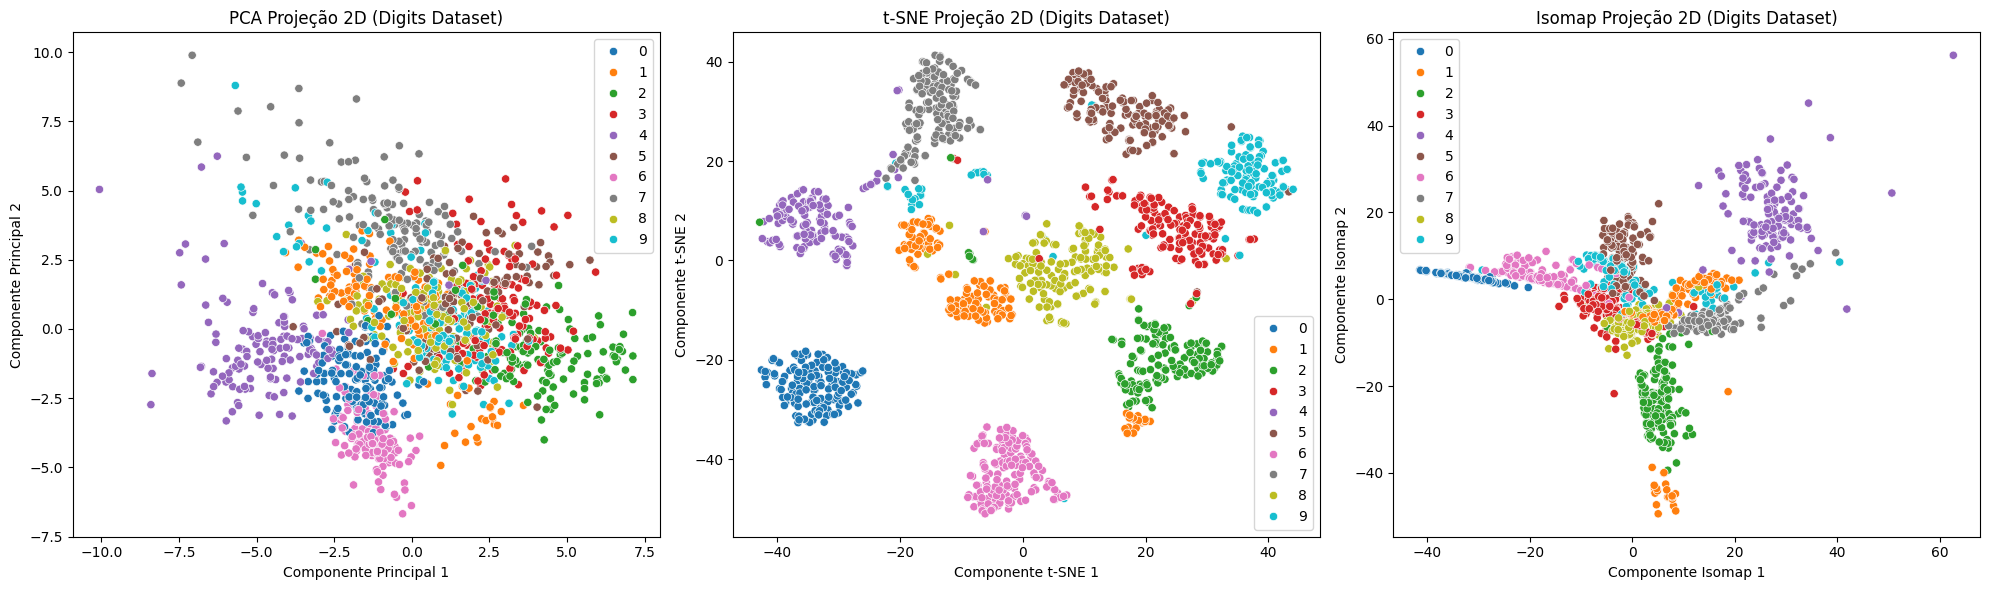

In [30]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE, Isomap
import matplotlib.pyplot as plt
import seaborn as sns

# a) Instanciar os modelos PCA, t-SNE e Isomap com n_components=2
pca_model = PCA(n_components=2, random_state=42)
tsne_model = TSNE(n_components=2, random_state=42, init='pca', learning_rate='auto') # init='pca' helps with reproducibility, learning_rate='auto' is default for newer versions
isomap_model = Isomap(n_components=2) # Isomap does not have random_state

# b) Aplicar os modelos sobre as variáveis numéricas escalonadas do conjunto de treinamento
X_digits_pca = pca_model.fit_transform(X_digits_train_scaled)
X_digits_tsne = tsne_model.fit_transform(X_digits_train_scaled)
X_digits_isomap = isomap_model.fit_transform(X_digits_train_scaled)

# c) Plotar três gráficos de dispersão (Scatter Plots) lado a lado
plt.figure(figsize=(20, 6))

# PCA Plot
plt.subplot(1, 3, 1)
sns.scatterplot(
    x=X_digits_pca[:, 0],
    y=X_digits_pca[:, 1],
    hue=y_digits_train,
    palette='tab10',
    legend='full'
)
plt.title('PCA Projeção 2D (Digits Dataset)')
plt.xlabel('Componente Principal 1')
plt.ylabel('Componente Principal 2')

# t-SNE Plot
plt.subplot(1, 3, 2)
sns.scatterplot(
    x=X_digits_tsne[:, 0],
    y=X_digits_tsne[:, 1],
    hue=y_digits_train,
    palette='tab10',
    legend='full'
)
plt.title('t-SNE Projeção 2D (Digits Dataset)')
plt.xlabel('Componente t-SNE 1')
plt.ylabel('Componente t-SNE 2')

# Isomap Plot
plt.subplot(1, 3, 3)
sns.scatterplot(
    x=X_digits_isomap[:, 0],
    y=X_digits_isomap[:, 1],
    hue=y_digits_train,
    palette='tab10',
    legend='full'
)
plt.title('Isomap Projeção 2D (Digits Dataset)')
plt.xlabel('Componente Isomap 1')
plt.ylabel('Componente Isomap 2')

plt.tight_layout()
plt.show()

### <font color='#2D9CDB'>Q25: Com base nos gráficos e na teoria da apostila, comente as diferenças visuais geradas pelos algoritmos na separação das classes, relacionando com suas naturezas matemáticas (linear global, não linear local e não linear global).</font>



 **PCA (Principal Component Analysis)**
*   **Natureza:** Linear e global.
*   **Análise Visual:** No gráfico do PCA, as classes (números de 0 a 9) tendem a estar mais misturadas e sobrepostas. Embora algumas classes possam apresentar uma leve separação, a distinção entre elas não é tão clara. Isso ocorre porque o PCA busca a projeção linear que maximiza a variância total dos dados, ou seja, ele tenta espalhar os dados o máximo possível. Ele não tem conhecimento das classes e não otimiza a separação entre elas, o que pode resultar em uma representação onde classes não linearmente separáveis permanecem entrelaçadas.

**t-SNE (t-distributed Stochastic Neighbor Embedding)**
*   **Natureza:** Não-linear e local.
*   **Análise Visual:** O gráfico do t-SNE exibe os clusters mais bem definidos e separados entre as classes. É possível observar agrupamentos compactos para cada número, com pouca sobreposição entre eles. Isso demonstra a eficácia do t-SNE em revelar estruturas de clusters e em enfatizar a separação de classes em baixa dimensão, tornando-o excelente para visualização.
*   **Explicação:** O t-SNE foca em preservar as distâncias locais entre os pontos. Ele transforma as distâncias euclidianas em probabilidades de similaridade e tenta replicar essas probabilidades no espaço de baixa dimensão, enfatizando que pontos próximos no espaço original permaneçam próximos e pontos distantes permaneçam distantes. Essa otimização para a estrutura local de vizinhança é o que resulta em clusters tão bem formados.

**Isomap (Isometric Mapping)**
*   **Natureza:** Não-linear e global (aprendizado de manifold).
*   **Análise Visual:** O gráfico do Isomap geralmente apresenta uma separação das classes melhor do que o PCA, mas talvez não tão

## <font color='green'>**3.7 Seleção de Atributos**</font>

## <font color='green'>Contextualização</font>

### <font color='#2D9CDB'>Acesse o link indicado e, em um único parágrafo, descreva brevemente o dataset, incluindo: domínio de aplicação, objetivo da base de dados e o tipo de informações que ela contém.</font>
- #### <font color='#2D9CDB'>M. Hopkins, E. Reeber, G. Forman, and J. Suermondt. "Spambase," UCI Machine Learning Repository, 1999. https://doi.org/10.24432/C53G6X</font>

O Spambase Dataset pertence ao domínio de filtragem de e-mails e segurança da informação, tendo como objetivo principal classificar mensagens como spam ou não spam (ham) com base em suas características. A base contém dados extraídos de e-mails, representados por atributos numéricos que indicam a frequência de determinadas palavras e caracteres (como termos comuns em spam), além de métricas relacionadas ao uso de letras maiúsculas. Ao todo, inclui diversas features quantitativas que descrevem o conteúdo textual das mensagens e uma variável alvo binária que indica se o e-mail é spam, sendo amplamente utilizado em tarefas de classificação supervisionada e detecção de spam.

## <font color='green'>Preparação</font>

In [31]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
ds_spam = fetch_ucirepo(id=94)

# data (as pandas dataframes)
X_spam = ds_spam.data.features
y_spam = ds_spam.data.targets

df_spam = pd.concat([X_spam, y_spam], axis='columns')
df_spam.head()

,word_freq_make,word_freq_address,word_freq_all,word_freq_3d,word_freq_our,word_freq_over,word_freq_remove,word_freq_internet,word_freq_order,word_freq_mail,...,char_freq_;,char_freq_(,char_freq_[,char_freq_!,char_freq_$,char_freq_#,capital_run_length_average,capital_run_length_longest,capital_run_length_total,Class
0,0.00,0.64,0.64,0.0,0.32,0.00,0.00,0.00,0.00,0.00,...,0.00,0.000,0.0,0.778,0.000,0.000,3.756,61,278,1
1,0.21,0.28,0.50,0.0,0.14,0.28,0.21,0.07,0.00,0.94,...,0.00,0.132,0.0,0.372,0.180,0.048,5.114,101,1028,1
2,0.06,0.00,0.71,0.0,1.23,0.19,0.19,0.12,0.64,0.25,...,0.01,0.143,0.0,0.276,0.184,0.010,9.821,485,2259,1
3,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.137,0.0,0.137,0.000,0.000,3.537,40,191,1
4,0.00,0.00,0.00,0.0,0.63,0.00,0.31,0.63,0.31,0.63,...,0.00,0.135,0.0,0.135,0.000,0.000,3.537,40,191,1


### <font color='#2D9CDB'>Q26: Divida o conjunto de dados em 80% para treinamento e 20% para teste. Em seguida, mostre o número de amostras (linhas) e características (colunas) de cada subconjunto.</font>

In [32]:
from sklearn.model_selection import train_test_split

# Dividir o conjunto de dados em treinamento (80%) e teste (20%)
X_spam_train, X_spam_test, y_spam_train, y_spam_test = train_test_split(
    X_spam, y_spam, test_size=0.2, random_state=42
)

# Mostrar o número de amostras (linhas) e características (colunas) de cada subconjunto
print(f"Shape de X_spam_train: {X_spam_train.shape}")
print(f"Shape de X_spam_test: {X_spam_test.shape}")
print(f"Shape de y_spam_train: {y_spam_train.shape}")
print(f"Shape de y_spam_test: {y_spam_test.shape}")

Shape de X_spam_train: (3680, 57)
Shape de X_spam_test: (921, 57)
Shape de y_spam_train: (3680, 1)
Shape de y_spam_test: (921, 1)


### <font color='#2D9CDB'>Q27: Aplique a técnica de Filtro de Baixa Variância (Variance Threshold) utilizando um limiar (threshold) de 0.01. Indique quais features seriam removidas do conjunto de dados por apresentarem variância abaixo deste valor.</spam>

In [33]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

# Instanciar o VarianceThreshold com o limiar de 0.01
selector = VarianceThreshold(threshold=0.01)

# Ajustar o seletor apenas no conjunto de treinamento
selector.fit(X_spam_train)

# Obter um array booleano indicando as features que foram mantidas (True) e removidas (False)
features_kept_mask = selector.get_support()

# Obter os nomes de todas as features originais
original_feature_names = X_spam_train.columns

# Identificar as features que seriam removidas
features_removed = original_feature_names[~features_kept_mask]

print(f"Número total de features originais: {X_spam_train.shape[1]}")
print(f"Número de features que seriam removidas (variância < 0.01): {len(features_removed)}")
print("\nFeatures que seriam removidas:")
if len(features_removed) > 0:
    for feature in features_removed:
        print(f"- {feature}")
else:
    print("Nenhuma feature seria removida com o limiar de 0.01.")


Número total de features originais: 57
Número de features que seriam removidas (variância < 0.01): 2

Features que seriam removidas:
- word_freq_table
- char_freq_[


### <font color='#2D9CDB'>Q28: Aplique o Filtro de Multicolinearidade gerando a matriz de correlação entre as features independentes. Identifique os pares de features que possuem uma correlação absoluta maior que 0.80 (∣r∣>0.80). Indique qual(is) feature(s) você removeria para eliminar a redundância.</font>

In [34]:
import pandas as pd

# Calcular a matriz de correlação
corr_matrix = X_spam_train.corr().abs()

# Selecionar pares de features com alta correlação (excluindo a diagonal e pares duplicados)
high_corr_pairs = []
features_to_remove = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if corr_matrix.iloc[i, j] > 0.80:
            colname_i = corr_matrix.columns[i]
            colname_j = corr_matrix.columns[j]
            high_corr_pairs.append((colname_j, colname_i, corr_matrix.iloc[i, j]))
            # Decidir qual feature remover (uma estratégia simples é remover a segunda no par)
            # Para evitar remover features que já foram identificadas em outros pares, usamos um set.
            features_to_remove.add(colname_i)

print("Pares de features com correlação absoluta maior que 0.80:")
if len(high_corr_pairs) > 0:
    for f1, f2, corr_val in high_corr_pairs:
        print(f"- {f1} e {f2}: {corr_val:.4f}")
    print("\nFeatures que poderiam ser removidas para eliminar redundância:")
    for feature in sorted(list(features_to_remove)):
        print(f"- {feature}")
else:
    print("Nenhum par de features com correlação absoluta maior que 0.80 encontrado.")


Pares de features com correlação absoluta maior que 0.80:
- word_freq_telnet e word_freq_857: 0.8223
- word_freq_telnet e word_freq_415: 0.8185
- word_freq_857 e word_freq_415: 0.9943
- word_freq_857 e word_freq_direct: 0.8867
- word_freq_415 e word_freq_direct: 0.8827

Features que poderiam ser removidas para eliminar redundância:
- word_freq_415
- word_freq_857
- word_freq_direct


### <font color='#2D9CDB'>Q29: Aplique o filtro de Correlação com o Alvo. Calcule a correlação de Pearson de cada feature com a variável alvo (Class). Indique quais features seriam removidas por possuírem uma correlação absoluta muito baixa, estritamente menor que 0.05 (∣r∣<0.05).</font>

In [35]:
import pandas as pd

# Calcular a correlação de Pearson de cada feature com a variável alvo 'Class'
# Certifique-se de que y_spam_train é uma Series para o método .corr()
correlations = X_spam_train.corrwith(y_spam_train['Class']).abs()

# Definir o limiar de correlação
threshold = 0.05

# Identificar as features com correlação absoluta menor que o limiar
features_to_remove_by_corr = correlations[correlations < threshold].index.tolist()

print("Features com correlação absoluta com a 'Class' menor que 0.05 (seriam removidas):")
if len(features_to_remove_by_corr) > 0:
    for feature in features_to_remove_by_corr:
        print(f"- {feature}: {correlations[feature]:.4f}")
else:
    print("Nenhuma feature seria removida com o limiar de 0.05.")


Features com correlação absoluta com a 'Class' menor que 0.05 (seriam removidas):
- word_freq_address: 0.0208
- word_freq_will: 0.0166
- word_freq_parts: 0.0276
- word_freq_table: 0.0391


### <font color='#2D9CDB'>Q28: Aplique a técnica de método de envelopamento RFE (Recursive Feature Elimination) utilizando um modelo de Regressão Logística ou Random Forest. Configure o algoritmo para selecionar apenas as 20 features mais importantes. Indique, de forma resumida, quais features foram descartadas pelo modelo.</font>
- #### <font color='#2D9CDB'>Utilize o modelo de [Regressão Logística](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) (`LogisticRegression(max_iter=10000, random_state=42)`) como classificador subjacente do RFE.</font>

In [36]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Instanciar o modelo de Regressão Logística
log_reg = LogisticRegression(max_iter=10000, random_state=42)

# Instanciar o RFE para selecionar as 20 features mais importantes
rfe_selector = RFE(estimator=log_reg, n_features_to_select=20, step=1)

# Ajustar o RFE no conjunto de treinamento
# y_spam_train precisa ser um array 1D para o RFE
rfe_selector.fit(X_spam_train, y_spam_train['Class'].values.ravel())

# Obter as features selecionadas e as descartadas
selected_features_mask = rfe_selector.support_
original_feature_names = X_spam_train.columns

features_discarded = original_feature_names[~selected_features_mask]
features_selected = original_feature_names[selected_features_mask]

print(f"Número total de features originais: {len(original_feature_names)}")
print(f"Número de features selecionadas pelo RFE: {len(features_selected)}")
print(f"Número de features descartadas pelo RFE: {len(features_discarded)}")

print("\nFeatures descartadas pelo modelo RFE:")
if len(features_discarded) > 0:
    for feature in features_discarded:
        print(f"- {feature}")
else:
    print("Nenhuma feature foi descartada pelo RFE (todas foram selecionadas).")


Número total de features originais: 57
Número de features selecionadas pelo RFE: 20
Número de features descartadas pelo RFE: 37

Features descartadas pelo modelo RFE:
- word_freq_make
- word_freq_address
- word_freq_all
- word_freq_3d
- word_freq_our
- word_freq_over
- word_freq_internet
- word_freq_mail
- word_freq_receive
- word_freq_will
- word_freq_people
- word_freq_report
- word_freq_email
- word_freq_you
- word_freq_your
- word_freq_font
- word_freq_money
- word_freq_650
- word_freq_labs
- word_freq_telnet
- word_freq_857
- word_freq_data
- word_freq_415
- word_freq_technology
- word_freq_1999
- word_freq_parts
- word_freq_direct
- word_freq_original
- word_freq_re
- word_freq_table
- char_freq_;
- char_freq_(
- char_freq_[
- char_freq_!
- capital_run_length_average
- capital_run_length_longest
- capital_run_length_total


### <font color='#2D9CDB'>Q30) O algoritmo RFE não apenas seleciona as variáveis, mas cria um ranking de importância para todas elas.</font>
- #### <font color='#2D9CDB'>a) Utilizando o atributo `.ranking_` do seletor ajustado na questão anterior, construa um DataFrame que mostre o nome das features originais lado a lado com sua posição no ranking. Ordene os resultados para exibir as features selecionadas (rank 1) no topo da tabela.</font>
- #### <font color='#2D9CDB'>b) Analisando o ranking, quais "termos" (palavras, símbolos de pontuação ou métricas de texto) o modelo considerou como os mais importantes para a detecção de spam (Rank 1)?</font>
- #### <font color='#2D9CDB'>c) Analisando o ranking, quais termos demonstraram ter o menor significado preditivo, sendo eliminados nas primeiras iterações (piores posições no ranking)?</font>

In [37]:
import pandas as pd

# a) Construir um DataFrame com o nome das features e seu ranking
feature_ranking = pd.DataFrame({
    'Feature': X_spam_train.columns,
    'Ranking': rfe_selector.ranking_
})

# Ordenar o DataFrame pelo ranking
feature_ranking_sorted = feature_ranking.sort_values(by='Ranking').reset_index(drop=True)

print("Ranking das Features pelo RFE:")
display(feature_ranking_sorted)

# b) Analisar os termos mais importantes (Rank 1)
rank_1_features = feature_ranking_sorted[feature_ranking_sorted['Ranking'] == 1]['Feature'].tolist()
print("\nb) Termos que o modelo considerou como os mais importantes para a detecção de spam (Rank 1):")
for feature in rank_1_features:
    print(f"- {feature}")

# c) Analisar os termos com menor significado preditivo (piores posições no ranking)
worst_rank_features = feature_ranking_sorted[feature_ranking_sorted['Ranking'] == feature_ranking_sorted['Ranking'].max()]['Feature'].tolist()
print("\nc) Termos que demonstraram ter o menor significado preditivo (piores posições no ranking):")
for feature in worst_rank_features:
    print(f"- {feature}")

Ranking das Features pelo RFE:


,Feature,Ranking
0,word_freq_remove,1
1,word_freq_addresses,1
2,word_freq_free,1
3,word_freq_order,1
4,word_freq_hp,1
5,word_freq_000,1
6,word_freq_credit,1
7,word_freq_business,1
8,word_freq_george,1
9,word_freq_hpl,1



b) Termos que o modelo considerou como os mais importantes para a detecção de spam (Rank 1):
- word_freq_remove
- word_freq_addresses
- word_freq_free
- word_freq_order
- word_freq_hp
- word_freq_000
- word_freq_credit
- word_freq_business
- word_freq_george
- word_freq_hpl
- word_freq_lab
- word_freq_edu
- word_freq_conference
- word_freq_meeting
- word_freq_pm
- word_freq_85
- char_freq_#
- word_freq_cs
- word_freq_project
- char_freq_$

c) Termos que demonstraram ter o menor significado preditivo (piores posições no ranking):
- capital_run_length_total
